# Đánh Giá Tổng Quan Dữ Liệu (Data Overview)

Notebook này thực hiện tổng quan dữ liệu từ thư mục `datathon-2026-round-1`:
- Kiểm tra kích thước (Shape) của từng bảng.
- Xác định Kiểu dữ liệu (Datatypes) của từng cột.
- Xem trước dữ liệu (Preview).
- Kiểm tra tỷ lệ khuyết thiếu dữ liệu (Missing Values).

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
data_dir = r"./datathon-2026-round-1"
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Kích Thước Tổng Quan Các Bảng
Chúng ta sẽ lướt qua tất cả các file CSV trong thư mục để xem số lượng dòng và cột của từng bảng.

In [2]:
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
overview_data = []

for fpath in csv_files:
    fname = os.path.basename(fpath)
    df = pd.read_csv(fpath)
    overview_data.append({
        "Table Name": fname,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Size (MB)": round(os.path.getsize(fpath) / (1024 * 1024), 2)
    })

df_overview = pd.DataFrame(overview_data).sort_values(by="Rows", ascending=False)
df_overview

C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1212414115.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath)


,Table Name,Rows,Columns,Size (MB)
4,order_items.csv,714669,7,22.83
3,orders.csv,646945,8,43.83
5,payments.csv,646945,4,17.53
12,shipments.csv,566067,4,18.84
0,customers.csv,121930,7,6.75
9,reviews.csv,113551,7,6.48
2,inventory.csv,60247,17,5.41
1,geography.csv,39948,4,1.34
8,returns.csv,39939,7,2.18
10,sales.csv,3833,3,0.12


## 2. Chi Tiết Kiểu Dữ Liệu và Phân Loại (Data Types Analysis)
Dưới đây là hàm tự động phân tích và phân loại các loại cột dữ liệu:
- **Numerical**: Các cột số liên tục.
- **Categorical**: Các cột phân loại/danh mục.
- **Time**: Các cột chứa thông tin thời gian/ngày tháng.
- **Text**: Các cột chứa văn bản dài (như tên sản phẩm, review).

In [3]:
def analyze_table_schema(file_name):
    fpath = os.path.join(data_dir, file_name)
    df = pd.read_csv(fpath)
    
    report = []
    for col in df.columns:
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        unique_count = df[col].nunique()
        
        # Phân loại datatype
        inferred_type = "unknown"
        sample_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        
        is_time = False
        if df[col].dtype == 'object':
            try:
                parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
                if parsed.notnull().all() and len(parsed) > 0:
                    is_time = True
            except:
                pass
        
        if is_time:
            inferred_type = "Time"
        elif pd.api.types.is_numeric_dtype(df[col]):
            if unique_count <= 10:
                inferred_type = "Categorical (Numeric)"
            else:
                inferred_type = "Numerical"
        elif df[col].dtype == 'object':
            avg_len = df[col].dropna().astype(str).str.len().mean() if not df[col].dropna().empty else 0
            if avg_len > 50 or unique_count > 1000:
                inferred_type = "Text/ID"
            else:
                inferred_type = "Categorical"
        else:
            inferred_type = str(df[col].dtype)
            
        report.append({
            "Column": col,
            "Inferred Type": inferred_type,
            "Pandas Dtype": df[col].dtype,
            "Null Count": null_count,
            "Null %": f"{null_pct:.2f}%",
            "Unique Values": unique_count,
            "Sample Value": str(sample_val)[:40] if sample_val is not None else "None"
        })
    
    print(f"=== SCHEMA REPORT: {file_name} ({df.shape[0]} rows, {df.shape[1]} cols) ===")
    return pd.DataFrame(report)

### Ví dụ phân tích Schema của bảng `orders.csv` và `sales.csv`:

In [4]:
analyze_table_schema("orders.csv")

C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\

=== SCHEMA REPORT: orders.csv (646945 rows, 8 cols) ===


,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,order_id,Numerical,int64,0,0.00%,646945,1
1,order_date,Time,object,0,0.00%,3833,2012-07-04
2,customer_id,Numerical,int64,0,0.00%,90246,58578
3,zip,Numerical,int64,0,0.00%,29932,1109
4,order_status,Categorical,object,0,0.00%,6,delivered
5,payment_method,Categorical,object,0,0.00%,5,credit_card
6,device_type,Categorical,object,0,0.00%,3,desktop
7,order_source,Categorical,object,0,0.00%,6,paid_search


In [5]:
analyze_table_schema("sales.csv")

=== SCHEMA REPORT: sales.csv (3833 rows, 3 cols) ===


,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,Date,Time,object,0,0.00%,3833,2012-07-04
1,Revenue,Numerical,float64,0,0.00%,3833,5123547.94
2,COGS,Numerical,float64,0,0.00%,3833,3982991.19


In [6]:
analyze_table_schema("order_items.csv")

C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath)
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')


=== SCHEMA REPORT: order_items.csv (714669 rows, 7 cols) ===


,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,order_id,Numerical,int64,0,0.00%,646945,1
1,product_id,Numerical,int64,0,0.00%,1598,2400
2,quantity,Categorical (Numeric),int64,0,0.00%,8,7
3,unit_price,Numerical,float64,0,0.00%,501330,1138.22
4,discount_amount,Numerical,float64,0,0.00%,204449,0.0
5,promo_id,Categorical,object,438353,61.34%,50,PROMO-0006
6,promo_id_2,Categorical,object,714463,99.97%,2,PROMO-0015


In [7]:
analyze_table_schema("geography.csv")

=== SCHEMA REPORT: geography.csv (39948 rows, 4 cols) ===


C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')


,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,zip,Numerical,int64,0,0.00%,39948,15201
1,city,Categorical,object,0,0.00%,42,Hai Phong
2,region,Categorical,object,0,0.00%,3,East
3,district,Categorical,object,0,0.00%,39,District #13


In [8]:
analyze_table_schema("products.csv")

=== SCHEMA REPORT: products.csv (2412 rows, 8 cols) ===


C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\

,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,product_id,Numerical,int64,0,0.00%,2412,536
1,product_name,Text/ID,object,0,0.00%,2172,SaigonFlex UC-01
2,category,Categorical,object,0,0.00%,4,Streetwear
3,segment,Categorical,object,0,0.00%,8,Everyday
4,size,Categorical,object,0,0.00%,4,S
5,color,Categorical,object,0,0.00%,10,green
6,price,Numerical,float64,0,0.00%,1990,11059.65
7,cogs,Numerical,float64,0,0.00%,2381,9704.842875


In [9]:
analyze_table_schema("inventory.csv")

=== SCHEMA REPORT: inventory.csv (60247 rows, 17 cols) ===


C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_7860\1989238854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[col].dropna().head(10), errors='coerce')


,Column,Inferred Type,Pandas Dtype,Null Count,Null %,Unique Values,Sample Value
0,snapshot_date,Time,object,0,0.00%,126,2022-10-31
1,product_id,Numerical,int64,0,0.00%,1624,1
2,stock_on_hand,Numerical,int64,0,0.00%,1895,3
3,units_received,Numerical,int64,0,0.00%,360,1
4,units_sold,Numerical,int64,0,0.00%,303,1
5,stockout_days,Numerical,int64,0,0.00%,29,2
6,days_of_supply,Numerical,float64,0,0.00%,9289,90.0
7,fill_rate,Numerical,float64,0,0.00%,29,0.9333
8,stockout_flag,Categorical (Numeric),int64,0,0.00%,2,1
9,overstock_flag,Categorical (Numeric),int64,0,0.00%,2,0


## 3. Xem Trước Dữ Liệu (Preview Data)
Hãy xem trước 3 dòng đầu tiên của một số bảng dữ liệu quan trọng nhất.

In [10]:
important_tables = ["orders.csv", "products.csv", "inventory.csv", "sales.csv", "promotions.csv"]
for table in important_tables:
    print(f"\n{'='*20} PREVIEW: {table} {'='*20}")
    df = pd.read_csv(os.path.join(data_dir, table))
    display(df.head(3))


==================== PREVIEW: orders.csv ====================


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct



==================== PREVIEW: products.csv ====================


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278



==================== PREVIEW: inventory.csv ====================


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12



==================== PREVIEW: sales.csv ====================


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84



==================== PREVIEW: promotions.csv ====================


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,3/18/2013,4/17/2013,NaN,email,1.0,0.0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,6/23/2013,7/22/2013,NaN,online,0.0,0.0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,8/30/2013,10/2/2013,NaN,email,0.0,0.0


## 4. Trực Quan Hóa Thiếu Hụt Dữ Liệu (Missing Values Visualizer)
Chúng ta sẽ xem nhanh tỷ lệ Null trong các bảng có dữ liệu bị khuyết.

C:\Users\PC\AppData\Local\Temp\ipykernel_7860\3169416330.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath)


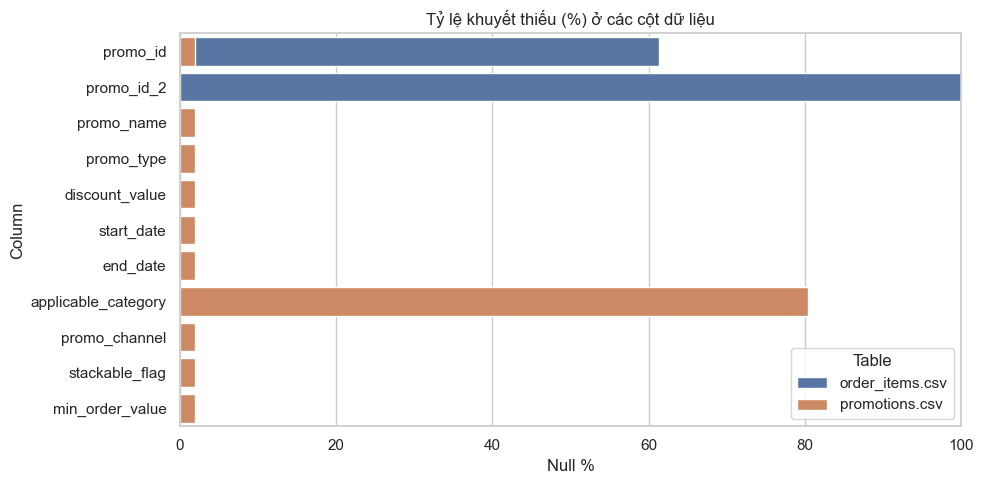

,Table,Column,Null Count,Null %
0,order_items.csv,promo_id,438353,61.34
1,order_items.csv,promo_id_2,714463,99.97
2,promotions.csv,promo_id,1,1.96
3,promotions.csv,promo_name,1,1.96
4,promotions.csv,promo_type,1,1.96
5,promotions.csv,discount_value,1,1.96
6,promotions.csv,start_date,1,1.96
7,promotions.csv,end_date,1,1.96
8,promotions.csv,applicable_category,41,80.39
9,promotions.csv,promo_channel,1,1.96


In [11]:
missing_reports = []
for fpath in csv_files:
    fname = os.path.basename(fpath)
    df = pd.read_csv(fpath)
    null_sum = df.isnull().sum()
    for col, null_val in null_sum.items():
        if null_val > 0:
            missing_reports.append({
                "Table": fname,
                "Column": col,
                "Null Count": null_val,
                "Null %": round((null_val / len(df)) * 100, 2)
            })

df_missing = pd.DataFrame(missing_reports)
if not df_missing.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_missing, x="Null %", y="Column", hue="Table", dodge=False)
    plt.title("Tỷ lệ khuyết thiếu (%) ở các cột dữ liệu")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()
    display(df_missing)
else:
    print("Tuyệt vời! Không có cột nào bị thiếu dữ liệu.")